# Exercise 5.3: Neural Networks in Keras

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# See https://keras.io/
# for extennsive documentation
import tensorflow as tf
from tensorflow import keras

from keras.models import Sequential
from keras.layers import Dense

Let us visit the problem of wine quality prediction previ- ously encountered in Exercises 3.2 and 4.1 one final time. After linear regression and a self-made network, we can now explore the comfort provided by the Keras library.

In [2]:
# The code snippet below is responsible for downloading the dataset to
# Google. You can directly download the file using the link
# if you work with a local anaconda setup
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv

--2026-08-26 12:14:26--  https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘winequality-white.csv.7’

winequality-white.c     [   <=>              ] 258.23K   381KB/s    in 0.7s    

2026-08-26 12:14:27 (381 KB/s) - ‘winequality-white.csv.7’ saved [264426]



In [3]:
# load all examples from the file
data = np.genfromtxt('winequality-white.csv',delimiter=";",skip_header=1)

print("data:", data.shape)

# Prepare for proper training
np.random.shuffle(data) # randomly sort examples

# take the first 3000 examples for training
X_train = data[:3000,:11] # all features except last column
y_train = data[:3000,11]  # quality column

# and the remaining examples for testing
X_test = data[3000:,:11] # all features except last column
y_test = data[3000:,11] # quality column

print("First example:")
print("Features:", X_train[0])
print("Quality:", y_train[0])

data: (4898, 12)
First example:
Features: [5.7000e+00 2.6000e-01 2.4000e-01 1.7800e+01 5.9000e-02 2.3000e+01
 1.2400e+02 9.9773e-01 3.3000e+00 5.0000e-01 1.0100e+01]
Quality: 5.0


Below is the simple network from exercise 4.1 implemented using Keras. In addition to the network we define the loss function and optimiser.

In [6]:
# See: https://keras.io/api/models/sequential/ and 
# https://keras.io/api/layers/core_layers/dense/
# We can use the Sequential class to very easiliy
# build a simple architecture
model = Sequential()
# 11 inputs, 20 outputs, relu
model.add(Dense(20, input_dim=11, activation='relu')) 
# 20 inputs (automatically detected by Keras), 1 output, linear activation
#one layer + output layer: loss function oscillates between 1 and 8
#+ 1 layers: loss mostly ~10, but one isolated peak to ~600
#n.b. too big learning rate! it was 0.1 -> switch to 0.001 and add a layer
#learning rate still too big
model.add(Dense(20,activation='relu'))
model.add(Dense(20,activation='relu'))
model.add(Dense(1, activation='linear'))

print (model.summary())


# Set loss function and optimiser algorithm
#optim=keras.optimizers.SGD(momentum=0.6)
optim=keras.optimizers.Adam(learning_rate=0.001)
#loss_model=keras.losses.MeanSquaredError()
model.compile(loss='mse',  # mean squared error
              optimizer=optim #sgd: stochastic gradient descent
             ) 





Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 20)                240       
                                                                 
 dense_5 (Dense)             (None, 20)                420       
                                                                 
 dense_6 (Dense)             (None, 20)                420       
                                                                 
 dense_7 (Dense)             (None, 1)                 21        
                                                                 
Total params: 1,101
Trainable params: 1,101
Non-trainable params: 0
_________________________________________________________________
None


# Training and evaluation below

The code below trains the network for 5 epochs using the loss function and optimiser defined above. Each example is individually passed to the network

In [7]:
history = model.fit(X_train, y_train, 
                    validation_data=(X_test, y_test),
                    epochs=60, batch_size=1)


Epoch 1/60
3000/3000 [==============================] - 31s 10ms/step - loss: 13.5857 - val_loss: 1.1308
Epoch 2/60
3000/3000 [==============================] - 30s 10ms/step - loss: 2.9943 - val_loss: 0.9323
Epoch 3/60
3000/3000 [==============================] - 30s 10ms/step - loss: 2.0391 - val_loss: 0.8584
Epoch 4/60
3000/3000 [==============================] - 30s 10ms/step - loss: 2.1068 - val_loss: 1.0840
Epoch 5/60
3000/3000 [==============================] - 31s 10ms/step - loss: 2.4119 - val_loss: 0.8319
Epoch 6/60
3000/3000 [==============================] - 30s 10ms/step - loss: 2.7069 - val_loss: 0.9855
Epoch 7/60
3000/3000 [==============================] - 31s 10ms/step - loss: 2.6642 - val_loss: 1.4700
Epoch 8/60
3000/3000 [==============================] - 30s 10ms/step - loss: 3.1235 - val_loss: 20.7083
Epoch 9/60
3000/3000 [==============================] - 30s 10ms/step - loss: 3.6154 - val_loss: 0.9054
Epoch 10/60
3000/3000 [==============================] - 30s 1

In [8]:
# The history object returned by the model training above 
# contains the values of the loss function (the mean-squared-error)
# at different epochs
# We discard the first epoch as the loss value is very high,
# obscuring the rest of the distribution
train_loss = history.history["loss"][1:]
test_loss = history.history["val_loss"][1:]

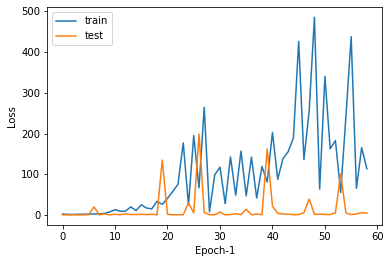

In [9]:
# Prepare and plot loss over time
plt.plot(train_loss,label="train")
plt.plot(test_loss,label="test")
plt.legend()
plt.xlabel("Epoch-1")
plt.ylabel("Loss")
plt.show()

In [ ]:
# After the training:

# Prepare scatter plot
y_pred = model.predict(X_test)[:,0]

print("Correlation coefficient:", np.corrcoef(y_pred,y_test)[0,1])
plt.scatter(y_pred,y_test)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
np.corrcoef(y_pred,y_test)


# Problems

* Use the notebook as starting point. It already contains the simple network from Exercise 4.1 implemented in Keras.

* Currently, SGD is used without momentum. Try training with a momentum term. Replace SGD with the Adam optimizer and train using that. (See: https://keras.io/api/optimizers/)
* Add two more hidden layers to the network (you can choose the number of nodes but make sure to apply the ReLu activation function after each) and train again.
* Test differet numbers of examples (i.e. change the batch batch size) to be simulataneously used by the network. 